### 1ª Etapa do Projeto - Análise Exploratória de Dados (EDA)
Disciplina: Eletiva \
Professor: Kelvin Frade Ribeiro

###  Integrantes da Equipe:
* Luiz Claudio Martins - 17252406
* Gabriel Normandio - 17252403
* Pethrus Souza - 17252412  

# 1ª Etapa do Projeto - Análise Exploratória de Dados (EDA)

### 1) **(5%)** Qual a base escolhida e qual seu interesse nela?

&gt; **Link da base no Kaggle:** [Hotel Booking Demand - Kaggle](https://www.kaggle.com/datasets/jessemostipak/hotel-booking-demand?resource=download)

&gt; **Motivação:** A base de dados *Hotel Booking Demand* reúne dados reais sobre reservas em dois hotéis de Portugal (um Resort e um Hotel Urbano) entre julho de 2015 e agosto de 2017\. A escolha desta base deve-se à sua grande relevância no setor hoteleiro, no qual o cancelamento de reservas gera grande impacto financeiro e operacional. Além disso, a base possui uma variável-alvo muito clara (`is_canceled`), o que nos permite investigar padrões comportamentais dos hóspedes nesta primeira etapa de Análise Exploratória (EDA) e reaproveitar os dados na próxima entrega do curso com modelos de Machine Learning.


### 2) **(5%)** Descrição básica do conjunto de dados escolhido pelo aluno (1 parágrafo).
- Identificação da variável a serem trabalhadas
- Classificação das variáveis como: contínua ou discreta.

&gt; **Descrição Geral:** O conjunto de dados possui **119.390 registros (linhas)** e **32 colunas/características**, contendo informações detalhadas sobre cancelamento de reservas, tempo de antecedência, datas de chegada, duração da estadia, perfil e país de origem dos hóspedes, canais de distribuição e modalidades de pagamento.

&gt; **Classificação das Variáveis Selecionadas:**

* **Variáveis Contínuas (Numéricas contínuas):**
  * `adr` (*Average Daily Rate*): Valor médio cobrado por diária.
  * `lead_time`: Quantidade de dias entre a data da reserva e a data de chegada ao hotel.
* **Variáveis Discretas (Numéricas discretas / contagens):**
  * `adults`, `children`, `babies`: Quantidade de adultos, crianças e bebês associados à reserva.
  * `stays_in_weekend_nights` / `stays_in_week_nights`: Número de pernoites em fins de semana e dias úteis.
  * `booking_changes`: Quantidade de alterações feitas na reserva antes do check-in.
  * `is_canceled`: Variável binária/discreta (0 = Não cancelado, 1 = Cancelado).
* **Variáveis Categóricas (Discretas Nominais):**
  * `hotel`: Categoria do estabelecimento (*Resort Hotel* ou *City Hotel*).
  * `country`: País de nacionalidade do hóspede.
  * `market_segment`: Segmento de mercado (ex: *Online TA*, *Corporate*, *Direct*).
  * `deposit_type`: Condição de depósito (*No Deposit*, *Non Refund*, *Refundable*).

### 3) **(15%)** Faça uma avaliação descritiva da sua base. Quantas linhas ela possui? Quais os tipos de dados? Quantas e quais features possuem?

Cada variável escolhida pelo aluno precisa passar por ao menos 1 pré-processamento. O pré-processamento pode ser (mas não está limitado a):
- Checagem se os valores estão dentro de um limite permitido ou razoável.
- Tratamento de valores ausentes por eliminação ou substituição.
- Conversão do tipo de dados.


In [14]:
import pandas as pd

# 1. Carregar a base de dados para o Pandas
df = pd.read_csv('hotel_bookings.csv')

# 2. Exibir o número de linhas e colunas
print("Número de linhas e colunas (linhas, colunas):", df.shape)

# 3. Junta os 5 primeiros com os 5 últimos registros
pd.concat([df.head(), df.tail()])

Número de linhas e colunas (linhas, colunas): (119390, 32)


,hotel,is_canceled,lead_time,arrival_date_year,arrival_date_month,arrival_date_week_number,arrival_date_day_of_month,stays_in_weekend_nights,stays_in_week_nights,adults,...,deposit_type,agent,company,days_in_waiting_list,customer_type,adr,required_car_parking_spaces,total_of_special_requests,reservation_status,reservation_status_date
0,Resort Hotel,0,342,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
1,Resort Hotel,0,737,2015,July,27,1,0,0,2,...,No Deposit,NaN,NaN,0,Transient,0.00,0,0,Check-Out,2015-07-01
2,Resort Hotel,0,7,2015,July,27,1,0,1,1,...,No Deposit,NaN,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
3,Resort Hotel,0,13,2015,July,27,1,0,1,1,...,No Deposit,304.0,NaN,0,Transient,75.00,0,0,Check-Out,2015-07-02
4,Resort Hotel,0,14,2015,July,27,1,0,2,2,...,No Deposit,240.0,NaN,0,Transient,98.00,0,1,Check-Out,2015-07-03
119385,City Hotel,0,23,2017,August,35,30,2,5,2,...,No Deposit,394.0,NaN,0,Transient,96.14,0,0,Check-Out,2017-09-06
119386,City Hotel,0,102,2017,August,35,31,2,5,3,...,No Deposit,9.0,NaN,0,Transient,225.43,0,2,Check-Out,2017-09-07
119387,City Hotel,0,34,2017,August,35,31,2,5,2,...,No Deposit,9.0,NaN,0,Transient,157.71,0,4,Check-Out,2017-09-07
119388,City Hotel,0,109,2017,August,35,31,2,5,2,...,No Deposit,89.0,NaN,0,Transient,104.40,0,0,Check-Out,2017-09-07
119389,City Hotel,0,205,2017,August,35,29,2,7,2,...,No Deposit,9.0,NaN,0,Transient,151.20,0,2,Check-Out,2017-09-07


In [15]:
# Exibir o tipo de dado de cada variável e a contagem de valores não-nulos
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119390 entries, 0 to 119389
Data columns (total 32 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   hotel                           119390 non-null  object 
 1   is_canceled                     119390 non-null  int64  
 2   lead_time                       119390 non-null  int64  
 3   arrival_date_year               119390 non-null  int64  
 4   arrival_date_month              119390 non-null  object 
 5   arrival_date_week_number        119390 non-null  int64  
 6   arrival_date_day_of_month       119390 non-null  int64  
 7   stays_in_weekend_nights         119390 non-null  int64  
 8   stays_in_week_nights            119390 non-null  int64  
 9   adults                          119390 non-null  int64  
 10  children                        119386 non-null  float64
 11  babies                          119390 non-null  int64  
 12  meal            

In [16]:
# Verificar apenas as colunas que possuem valores nulos (> 0)
df.isnull().sum()[df.isnull().sum() > 0]

,0
children,4
country,488
agent,16340
company,112593


In [17]:
# A) Tratamento de Valores Ausentes (Substituição)
# Preencher nulos de crianças com 0
df['children'] = df['children'].fillna(0)

# Preencher países ausentes com 'Desconhecido'
df['country'] = df['country'].fillna('Unknown')

# B) Conversão de Tipo de Dados
# Converter 'children' de float para int (número inteiro de crianças)
df['children'] = df['children'].astype(int)

# C) Checagem de limites / Remoção de inconsistências (ex: reservas com 0 adultos, 0 crianças e 0 bebês)
sem_hospedes = (df['adults'] == 0) & (df['children'] == 0) & (df['babies'] == 0)
df = df[~sem_hospedes]

# Confirmar que os nulos das colunas tratadas foram zerados
print("Linhas restantes após remoção de inconsistências:", df.shape)

Linhas restantes após remoção de inconsistências: (119210, 32)


### 4) **(60%)** Nos blocos seguintes construa análises que vão justificar suas conclusões.

#### 4.1) **(20%)** Análise 1 -  Distribuição dos valores para cada uma das variáveis
- Exemplo para variável contínua: se o conjunto de dados possui a variável "idade". Quantos % possui a idade entre 0 e 30 anos? 31 a 59? 60+?

- Exemplo para variável discreta: se o conjunto de dados possui a variável "gênero", quantos % do conjunto de dados é do sexo feminino, quantos % é masculino? Inclua outros gêneros se houver.


/tmp/ipykernel_1335/3953145727.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(x='is_canceled', data=df, palette='Set2')


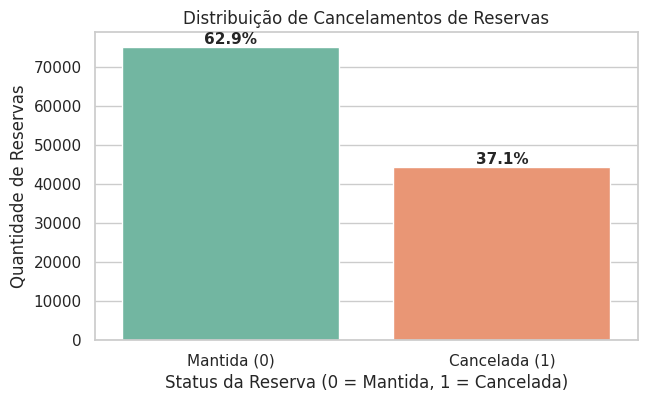

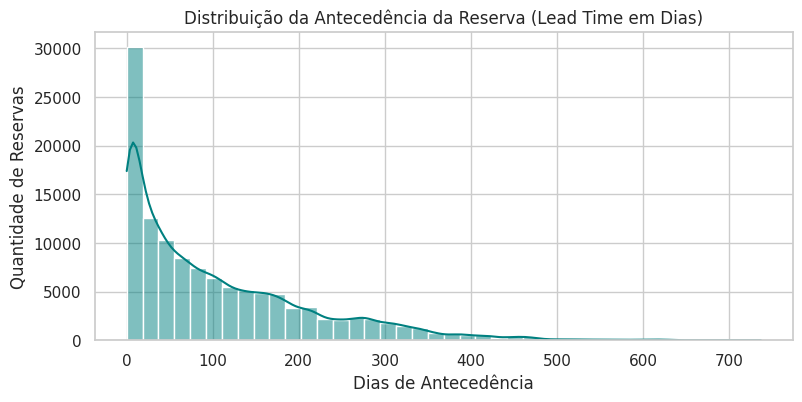

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# --- Gráfico 1: Distribuição de Cancelamentos (Variável Discreta) ---
plt.figure(figsize=(7, 4))
ax = sns.countplot(x='is_canceled', data=df, palette='Set2')
plt.title('Distribuição de Cancelamentos de Reservas', fontsize=12)
plt.xlabel('Status da Reserva (0 = Mantida, 1 = Cancelada)')
plt.ylabel('Quantidade de Reservas')
plt.xticks([0, 1], ['Mantida (0)', 'Cancelada (1)'])

# Exibir percentuais no topo das barras
total = len(df)
for p in ax.patches:
  percentage = f'{100 * p.get_height() / total:.1f}%'
  ax.annotate(percentage, (p.get_x() + p.get_width() / 2., p.get_height()),
              ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.show()

# --- Gráfico 2: Distribuição do Tempo de Antecedência (Variável Contínua) ---
plt.figure(figsize=(9, 4))
sns.histplot(df['lead_time'], bins=40, kde=True, color='teal')
plt.title('Distribuição da Antecedência da Reserva (Lead Time em Dias)', fontsize=12)
plt.xlabel('Dias de Antecedência')
plt.ylabel('Quantidade de Reservas')
plt.show()

&gt; **Análise do Item 4.1:**

* **Cancelamentos (** **is\_canceled** **):** A maioria das reservas (\~63%) é mantida, enquanto cerca de **37% das reservas são canceladas**. Essa alta taxa de cancelamento reforça a importância de investigar quais fatores influenciam o comportamento do cliente.
* **Antecedência (** **lead\_time** **):** A distribuição é assimétrica à esquerda, mostrando que a maior concentração de reservas é feita com **poucos dias de antecedência** (próximo de 0 a 50 dias), embora existam casos pontuais de reservas feitas com mais de 400 dias de antecedência.

#### 4.2) **(20%)** Análise 2 - Dependência entre variáveis



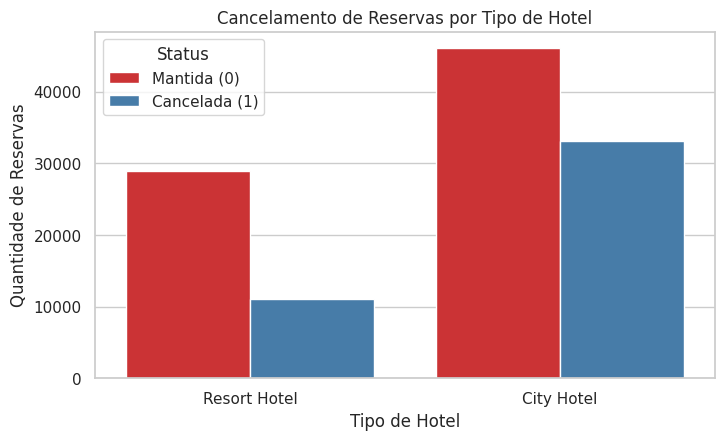

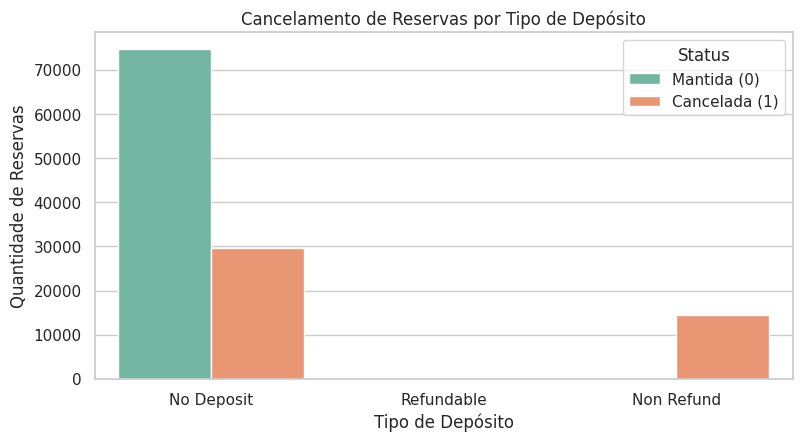

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar o estilo visual dos gráficos
sns.set_theme(style="whitegrid")

# --- Gráfico 1: Cancelamento por Tipo de Hotel ---
plt.figure(figsize=(8, 4.5))
ax1 = sns.countplot(x='hotel', hue='is_canceled', data=df, palette='Set1')
plt.title('Cancelamento de Reservas por Tipo de Hotel', fontsize=12)
plt.xlabel('Tipo de Hotel')
plt.ylabel('Quantidade de Reservas')
plt.legend(title='Status', labels=['Mantida (0)', 'Cancelada (1)'])
plt.show()

# --- Gráfico 2: Cancelamento por Tipo de Depósito ---
plt.figure(figsize=(9, 4.5))
ax2 = sns.countplot(x='deposit_type', hue='is_canceled', data=df, palette='Set2')
plt.title('Cancelamento de Reservas por Tipo de Depósito', fontsize=12)
plt.xlabel('Tipo de Depósito')
plt.ylabel('Quantidade de Reservas')
plt.legend(title='Status', labels=['Mantida (0)', 'Cancelada (1)'])
plt.show()

&gt; **Análise do Item 4.2 (Dependência entre Variáveis):**

* **Tipo de Hotel (** **hotel** **vs** **is\_canceled** **):** O *City Hotel* (Hotel Urbano) registra um volume consideravelmente maior de reservas no total e também apresenta uma proporção maior de cancelamentos quando comparado ao *Resort Hotel*.
* **Tipo de Depósito (** **deposit\_type** **vs** **is\_canceled** **):** A imensa maioria das reservas é realizada sob a modalidade *No Deposit* (sem exigência de depósito prévio). Curiosamente, as reservas com depósito do tipo *Non Refund* (não reembolsável) concentram uma taxa de cancelamento extremamente elevada, o que sugere um padrão diferenciado em reservas feitas por pacotes de agências de turismo ou grupos empresariais.

#### 4.3) **(20%)** Análise 3 - Correlação entre variáveis

O aluno deve apresentar 3 análises de correlação entre variáveis do conjunto de dados trabalhado. Exemplo: Em um conjunto de dados com as informações de temperatura e ocorrência de incêndios, eu gostaria de saber a incidência de correlação entre as duas variáveis.



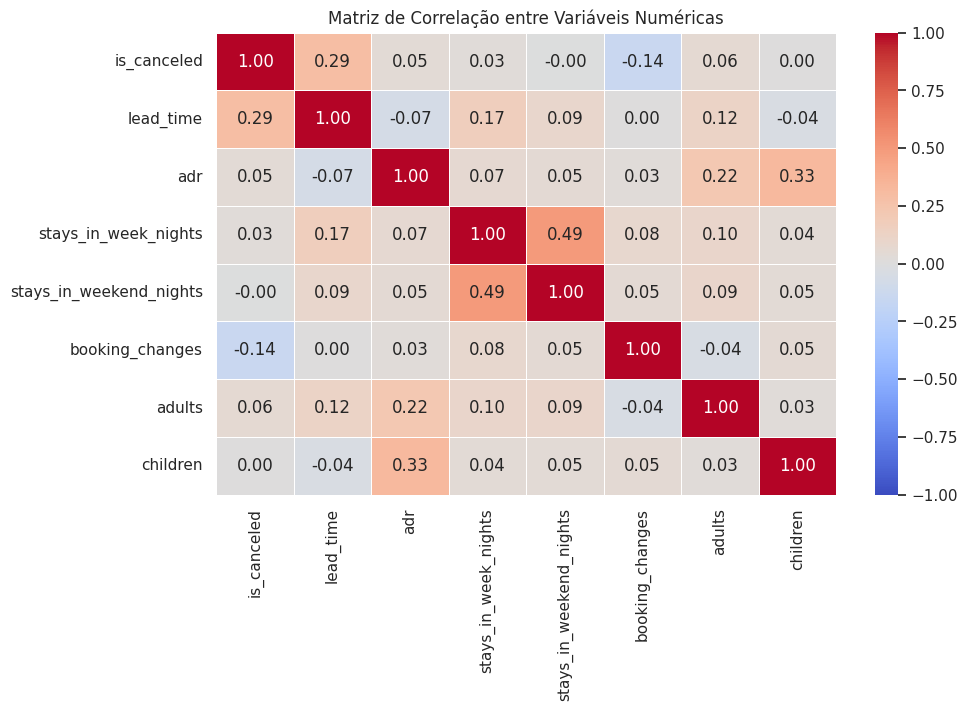

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Selecionar as principais variáveis numéricas para análise de correlação
colunas_numericas = [
    'is_canceled',
    'lead_time',
    'adr',
    'stays_in_week_nights',
    'stays_in_weekend_nights',
    'booking_changes',
    'adults',
    'children'
]
# 2. Calcular a matriz de correlação de Pearson
matriz_corr = df[colunas_numericas].corr()

# 3. Plotar o Mapa de Calor (Heatmap)
plt.figure(figsize=(10, 6))
sns.heatmap(matriz_corr, annot=True, fmt='.2f', cmap='coolwarm', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matriz de Correlação entre Variáveis Numéricas', fontsize=12)
plt.show()

&gt; **Análise do Item 4.3 (3 Análises de Correlação entre Variáveis):**

1. **lead\_time** **vs** **is\_canceled** **(Correlação Positiva):** Existe uma correlação positiva moderada de cerca de **+0.29** entre a antecedência da reserva e o cancelamento. Isso indica que **quanto maior a antecedência com que a reserva é realizada, maior é a probabilidade de ela ser cancelada**.
2. **stays\_in\_week\_nights** **vs** **stays\_in\_weekend\_nights** **(Correlação Positiva Forte):** Apresenta correlação positiva expressiva (**+0.49**). Isso reflete a dinâmica natural das estadias: clientes que passam mais dias úteis no hotel tendem também a estender a permanência durante os fins de semana.
3. **booking\_changes** **vs** **is\_canceled** **(Correlação Negativa):** Observa-se uma correlação negativa (**\-0.14**) entre alterações na reserva e cancelamentos. Hóspedes que realizam alterações prévias na reserva (mudança de datas, tipo de quarto, etc.) demonstram maior intenção de comparecimento e, portanto, **cancelam menos**.

### 5) Conclusões **15%**

*O que é possível concluir com os dados que você analisou? Se fosse fazer uma apresentação, o que levaria como os maiores destaques e por que?*

# Conclusões

&gt; A Análise Exploratória de Dados (EDA) realizada sobre a base *Hotel Booking Demand* permitiu extrair *insights* valiosos a respeito do padrão de comportamento dos hóspedes e dos principais fatores associados ao cancelamento de reservas.

### Principais Insights Descobertos:

1. **Volume Significativo de Cancelamentos:** A taxa geral de cancelamento é elevada (\~37%), com destaque para o **City Hotel**, que apresenta um volume absoluto e proporcional de cancelamentos bem superior ao **Resort Hotel**.
2. **Relação da Antecedência (** **lead\_time** **) com o Cancelamento:** Identificou-se uma correlação positiva (+0.29) que demonstra que reservas efetuadas com **muita antecedência** têm maior probabilidade de serem canceladas do que reservas de última hora.
3. **Impacto da Modalidade de Depósito:** A expressiva maioria das reservas ocorre sem depósito prévio (*No Deposit*). No entanto, o segmento *Non Refund* (não reembolsável) concentra um padrão atípico de cancelamento, associado a reservas de grupos e agências.
4. **Engajamento e Alterações na Reserva (** **booking\_changes** **):** Hóspedes que realizam alterações prévias em suas reservas tendem a cancelar menos (correlação -0.14), demonstrando maior intenção de comparecimento.

### Recomendações e Próximos Passos para a Próxima Entrega:

&gt; Para uma apresentação executiva, destaca-se a necessidade de adotar **políticas dinâmicas de overbooking** e **estratégias de retenção** direcionadas a reservas feitas com grande antecedência no *City Hotel*.

&gt; Além disso, como a variável **is\_canceled** apresentou um comportamento claro e consistente frente às demais características da base, este conjunto de dados limpo e pré-processado encontra-se idealmente estruturado para o desenvolvimento de **modelos preditivos de Machine Learning** na 2ª etapa do projeto.